# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
columns_to_drop = ["land", "urgent", "numfailedlogins", "numoutboundcmds"]

data.drop(columns=columns_to_drop, inplace=True)

data

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
data.loc[data["attack"] != "normal", "attack"] = "attack"

data["attack"].value_counts()

attack
normal    67343
attack    58630
Name: count, dtype: int64

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
categorical_columns = ["protocoltype", "service", "flag", "attack"]

for column in categorical_columns:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

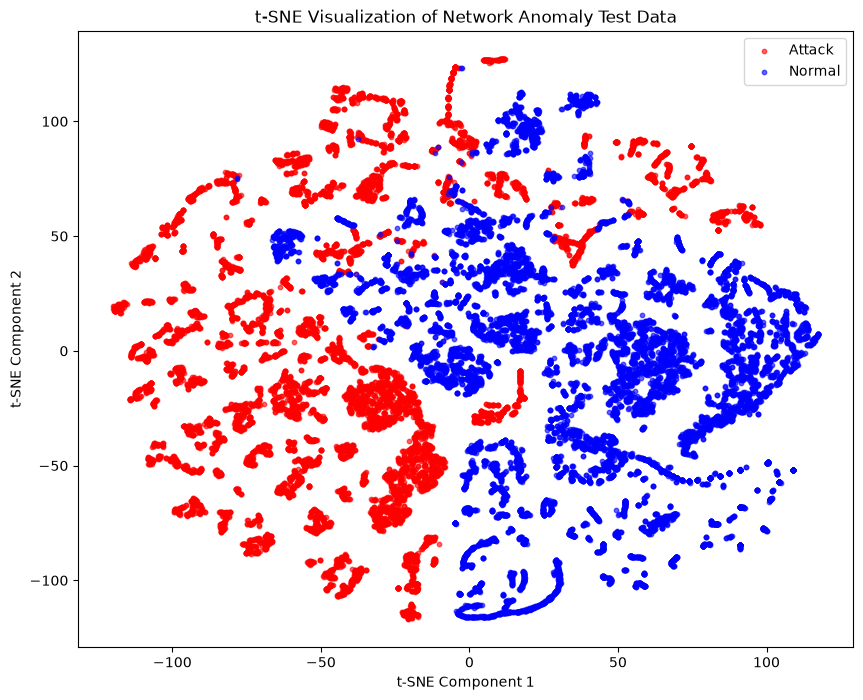

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

y_test_flat = y_test.ravel()

plt.figure(figsize=(10, 8))

plt.scatter(
    X_test_tsne[y_test_flat == 0, 0],
    X_test_tsne[y_test_flat == 0, 1],
    c="red",
    label="Attack",
    s=10,
    alpha=0.6
)

plt.scatter(
    X_test_tsne[y_test_flat == 1, 0],
    X_test_tsne[y_test_flat == 1, 1],
    c="blue",
    label="Normal",
    s=10,
    alpha=0.6
)

plt.title("t-SNE Visualization of Network Anomaly Test Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

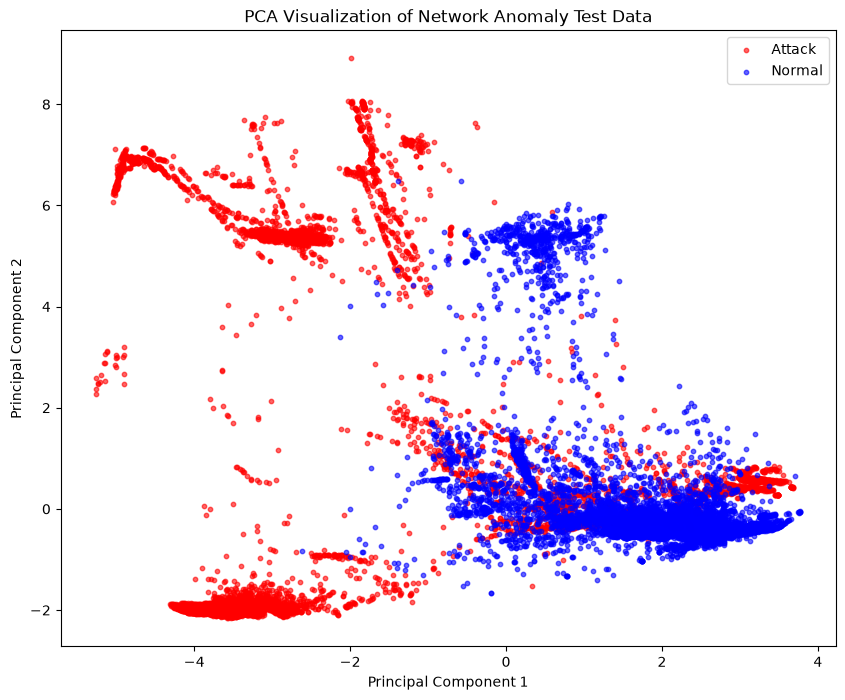

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

y_test_flat = y_test.ravel()

plt.figure(figsize=(10, 8))

plt.scatter(
    X_test_pca[y_test_flat == 0, 0],
    X_test_pca[y_test_flat == 0, 1],
    c="red",
    label="Attack",
    s=10,
    alpha=0.6
)

plt.scatter(
    X_test_pca[y_test_flat == 1, 0],
    X_test_pca[y_test_flat == 1, 1],
    c="blue",
    label="Normal",
    s=10,
    alpha=0.6
)

plt.title("PCA Visualization of Network Anomaly Test Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

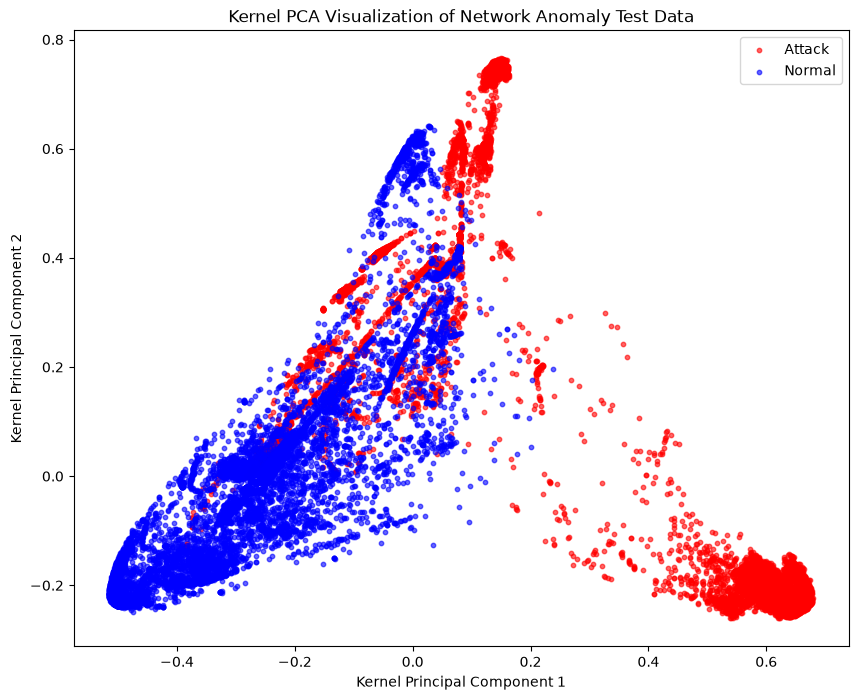

In [12]:
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(
    n_components=2,
    kernel="rbf",
    random_state=42
)

X_test_kernel_pca = kernel_pca.fit_transform(X_test)

y_test_flat = y_test.ravel()

plt.figure(figsize=(10, 8))

plt.scatter(
    X_test_kernel_pca[y_test_flat == 0, 0],
    X_test_kernel_pca[y_test_flat == 0, 1],
    c="red",
    label="Attack",
    s=10,
    alpha=0.6
)

plt.scatter(
    X_test_kernel_pca[y_test_flat == 1, 0],
    X_test_kernel_pca[y_test_flat == 1, 1],
    c="blue",
    label="Normal",
    s=10,
    alpha=0.6
)

plt.title("Kernel PCA Visualization of Network Anomaly Test Data")
plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")
plt.legend()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure that the output layer contains one neuron with sigmoid activation.

In [13]:
# Define the DNN model
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation='sigmoid')
])

base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2496      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5121 (20.00 KB)
Trainable params: 5121 (20.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = base_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
2520/2520 [==============================] - 1s 320us/step - loss: 0.0276 - accuracy: 0.9906 - val_loss: 0.0134 - val_accuracy: 0.9956
Epoch 2/20
2520/2520 [==============================] - 1s 298us/step - loss: 0.0099 - accuracy: 0.9964 - val_loss: 0.0092 - val_accuracy: 0.9971
Epoch 3/20
2520/2520 [==============================] - 1s 293us/step - loss: 0.0076 - accuracy: 0.9969 - val_loss: 0.0056 - val_accuracy: 0.9974
Epoch 4/20
2520/2520 [==============================] - 1s 288us/step - loss: 0.0064 - accuracy: 0.9975 - val_loss: 0.0079 - val_accuracy: 0.9970
Epoch 5/20
2520/2520 [==============================] - 1s 288us/step - loss: 0.0061 - accuracy: 0.9978 - val_loss: 0.0060 - val_accuracy: 0.9975
Epoch 6/20
2520/2520 [==============================] - 1s 288us/step - loss: 0.0051 - accuracy: 0.9983 - val_loss: 0.0052 - val_accuracy: 0.9984
Epoch 7/20
2520/2520 [==============================] - 1s 288us/step - loss: 0.0042 - accuracy: 0.9984 - val_loss: 0.0044 -

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report:
              precision    recall  f1-score   support

      Attack     0.9985    0.9980    0.9983     11777
      Normal     0.9983    0.9987    0.9985     13418

    accuracy                         0.9984     25195
   macro avg     0.9984    0.9984    0.9984     25195
weighted avg     0.9984    0.9984    0.9984     25195

Confusion Matrix:
[[11754    23]
 [   18 13400]]


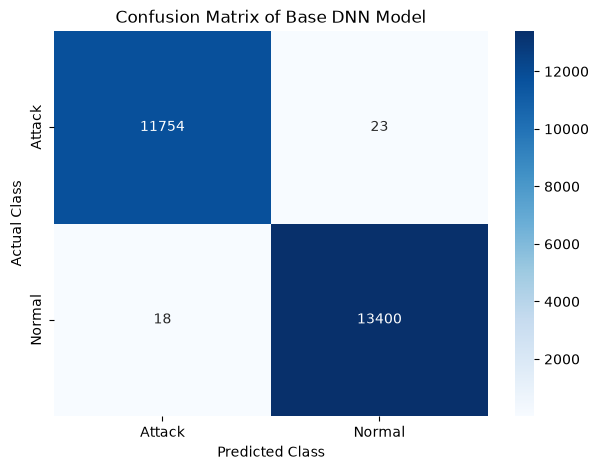

In [15]:
# Obtain sigmoid probabilities from the trained model
y_pred_prob = base_model.predict(X_test, verbose=0).ravel()

# Convert probabilities into binary class labels
y_pred = (y_pred_prob >= 0.5).astype(int)

# Convert the actual labels into a one-dimensional array
y_true = y_test.ravel().astype(int)

# Print classification report
print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Attack", "Normal"],
        digits=4
    )
)

# Calculate and print confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Attack", "Normal"],
    yticklabels=["Attack", "Normal"]
)

plt.title("Confusion Matrix of Base DNN Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement full-integer INT8 post-training quantization on the base_model. Use a representative dataset from X_train to calibrate the activation ranges. Configure the converter to use INT8 operators with INT8 input and output tensors. Designate the resulting quantized model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Select 1000 training samples for representative calibration
rng = np.random.default_rng(42)

representative_indices = rng.choice(
    len(X_train),
    size=min(1000, len(X_train)),
    replace=False
)

# Define the representative dataset generator
def representative_dataset():
    for index in representative_indices:
        sample = X_train[index:index + 1].astype(np.float32)
        yield [sample]


# Create a TensorFlow Lite converter from the trained Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)

# Enable post-training quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Provide representative samples for activation calibration
converter.representative_dataset = representative_dataset

# Require all model operations to use INT8 implementations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# Require INT8 input and output tensors
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert the model
tflite_quant_model = converter.convert()

print("Full-integer INT8 quantization completed.")

INFO:tensorflow:Assets written to: /var/folders/vd/_brkz_g91_g7w7y_bryvtkhh0000gn/T/tmpe_rc5v3x/assets


INFO:tensorflow:Assets written to: /var/folders/vd/_brkz_g91_g7w7y_bryvtkhh0000gn/T/tmpe_rc5v3x/assets


Full-integer INT8 quantization completed.


2026-08-18 15:08:46.015896: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-08-18 15:08:46.015919: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-08-18 15:08:46.016245: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/vd/_brkz_g91_g7w7y_bryvtkhh0000gn/T/tmpe_rc5v3x
2026-08-18 15:08:46.016604: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-08-18 15:08:46.016609: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/vd/_brkz_g91_g7w7y_bryvtkhh0000gn/T/tmpe_rc5v3x
2026-08-18 15:08:46.018061: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-08-18 15:08:46.018413: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-08-18 15:08:46.035892: I tensorflow/cc/saved_model/loader.

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.01 KB
Quantized model size: 8.24 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Input dtype: <class 'numpy.int8'>
Input scale: 0.21010369062423706
Input zero point: -87
Output dtype: <class 'numpy.int8'>
Output scale: 0.00390625
Output zero point: -128

Classification Report for INT8 TFLite Model:
              precision    recall  f1-score   support

      Attack     0.9983    0.9982    0.9983     11777
      Normal     0.9984    0.9985    0.9985     13418

    accuracy                         0.9984     25195
   macro avg     0.9984    0.9984    0.9984     25195
weighted avg     0.9984    0.9984    0.9984     25195

Confusion Matrix for INT8 TFLite Model:
[[11756    21]
 [   20 13398]]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


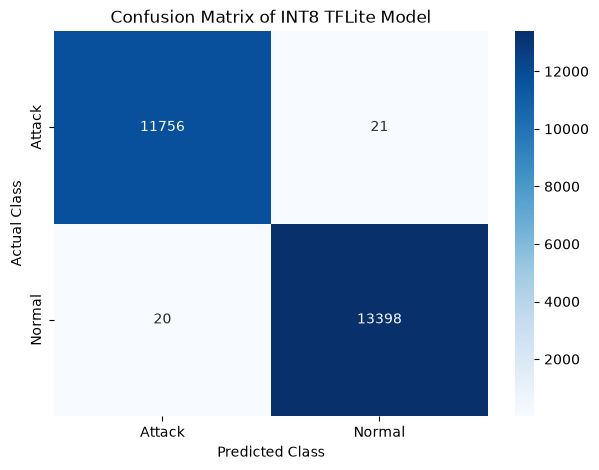

In [19]:
# Create and initialize the TensorFlow Lite interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

# Obtain input and output tensor information
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale, input_zero_point = input_details["quantization"]
output_scale, output_zero_point = output_details["quantization"]

print("Input dtype:", input_details["dtype"])
print("Input scale:", input_scale)
print("Input zero point:", input_zero_point)

print("Output dtype:", output_details["dtype"])
print("Output scale:", output_scale)
print("Output zero point:", output_zero_point)


# Store predictions from the quantized model
quantized_predictions = []

for sample in X_test:
    # Add the batch dimension and convert to float32
    sample = sample.reshape(1, -1).astype(np.float32)

    # Quantize the float input into INT8
    quantized_input = np.round(
        sample / input_scale + input_zero_point
    )

    quantized_input = np.clip(
        quantized_input,
        np.iinfo(np.int8).min,
        np.iinfo(np.int8).max
    ).astype(np.int8)

    # Run inference
    interpreter.set_tensor(
        input_details["index"],
        quantized_input
    )
    interpreter.invoke()

    # Read the quantized INT8 output
    quantized_output = interpreter.get_tensor(
        output_details["index"]
    )[0][0]

    # Dequantize the output back to a sigmoid probability
    output_probability = (
        float(quantized_output) - output_zero_point
    ) * output_scale

    # Convert the probability to a binary class
    predicted_class = 1 if output_probability >= 0.5 else 0
    quantized_predictions.append(predicted_class)


# Convert results into NumPy arrays
y_pred_quantized = np.array(quantized_predictions, dtype=int)
y_true = y_test.ravel().astype(int)


# Print classification report
print("\nClassification Report for INT8 TFLite Model:")
print(
    classification_report(
        y_true,
        y_pred_quantized,
        labels=[0, 1],
        target_names=["Attack", "Normal"],
        digits=4
    )
)


# Calculate and print confusion matrix
cm_quantized = confusion_matrix(
    y_true,
    y_pred_quantized,
    labels=[0, 1]
)

print("Confusion Matrix for INT8 TFLite Model:")
print(cm_quantized)


# Visualize the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_quantized,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Attack", "Normal"],
    yticklabels=["Attack", "Normal"]
)

plt.title("Confusion Matrix of INT8 TFLite Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## Converting tflite_quant_model to C and creating the header file

In [20]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [21]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [22]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, 1.0873051789289023, 
    -2.2235805674567635, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    3.710586841256697, -0.3681102129968653, -0.592411804799424, 
    -0.6319290328885425, 2.652779844033387, 2.715364578035608, 
    -1.5034028912616122, 5.196207521885405, -0.37455970440553465, 
    0.7343425609306344, -1.0356876376568842, -1.161030186584037, 
    4.854138229556743, -0.4801968475158174, -0.28910340026287856, 
    -0.617048995298306, -0.6248707997445304, 2.7765482226806206, 
    2.753913722653446, 0.21642633142264128, -0.11024922321249885, 
    -0

In [23]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    0, 0, 0, 0, 0
};



In [24]:
ytest = y_test[0:5].ravel().astype(np.uint8)

print("ytest shape:", ytest.shape)
print(c_writer.create_array(ytest, "uint8_t", "y_test"))

ytest shape: (5,)
const unsigned int y_test_dim1 = 5;

const uint8_t y_test[5] = {
    0, 0, 0, 0, 0
};



In [25]:
Xtest = X_test[5:15, :]
print(c_writer.create_array(Xtest, "float", "X_test"))

ytest = y_test[5:15].ravel().astype(np.uint8)
print(c_writer.create_array(ytest, "uint8_t", "y_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.007723912256862794, -0.003957003866021079, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6646474761387667, -0.271738672199746, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.11945927639741905, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.4478339589698615, -0.20026454391970344, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922